In [6]:
import requests

# Global Surface Water - JRC/Google via Earth Engine Data Catalog
# Versão estática que não precisa de autenticação
url = "https://storage.googleapis.com/global-surface-water/downloads2021/occurrence/occurrence_70W_0Nv1_4_2021.tif"

response = requests.get(url, timeout=120, stream=True)
print("Status:", response.status_code)
print("Tamanho:", response.headers.get('content-length', 'unknown'), "bytes")
# Tile correto para a ilha

Status: 200
Tamanho: 48326120 bytes


In [7]:
import requests
import numpy as np
import rasterio
from rasterio.transform import rowcol
from io import BytesIO

# Tile que cobre Manaus (-3 lat, -60 lon)
url = "https://storage.googleapis.com/global-surface-water/downloads2021/occurrence/occurrence_60W_0Nv1_4_2021.tif"

response = requests.get(url, timeout=60, stream=True)
print("Status:", response.status_code)

with rasterio.open(BytesIO(response.content)) as dataset:
    print("Bounds:", dataset.bounds)
    
    data = dataset.read(1)
    
    ilha_lat, ilha_lon = -3.2847, -60.2
    row, col = rowcol(dataset.transform, ilha_lon, ilha_lat)
    
    print(f"Valor em Manaus: {data[row, col]}")
    
    # Mostra area ao redor de Manaus
    sample = data[max(0,row-50):row+50, max(0,col-50):col+50]
    print(f"Valores na regiao de Manaus: min={sample.min()}, max={sample.max()}")
    print(f"Pixels sazonais (20-80): {np.sum((sample > 20) & (sample < 80))}")

Status: 200
Bounds: BoundingBox(left=-60.0, bottom=-10.0, right=-50.0, top=0.0)
Valor em Manaus: 0
Valores na regiao de Manaus: min=0, max=100
Pixels sazonais (20-80): 173631


Baixando tile...
Status: 200 | Tamanho: 46 MB
Bounds: BoundingBox(left=-70.0, bottom=-10.0, right=-60.0, top=0.0)
Row: 13355, Col: 39256
Valor no pixel da ilha: 1
Crop shape: (4000, 2744)


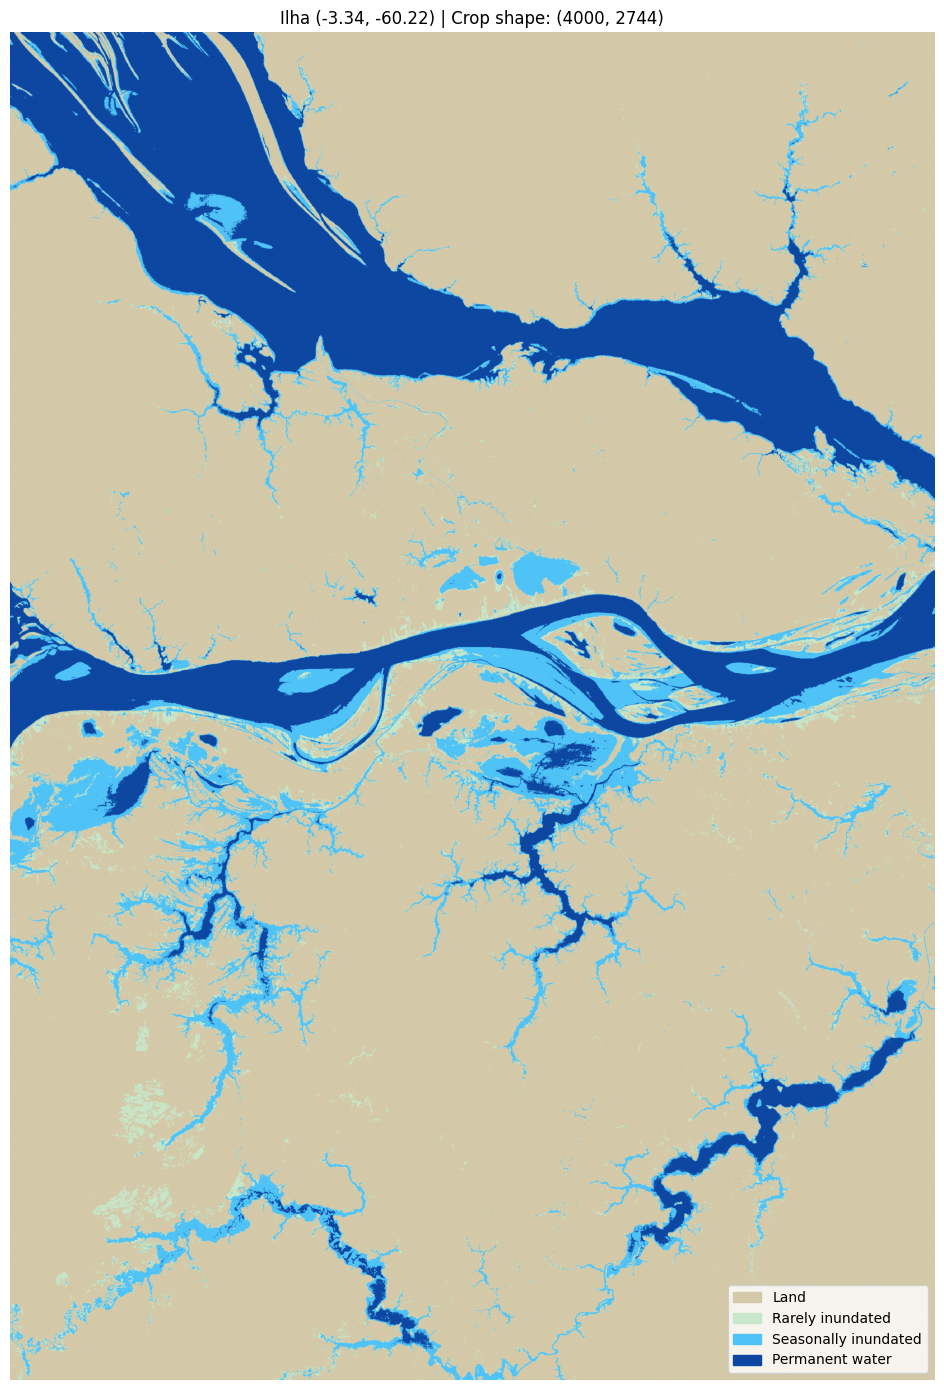

In [10]:
import requests
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from io import BytesIO

url = "https://storage.googleapis.com/global-surface-water/downloads2021/occurrence/occurrence_70W_0Nv1_4_2021.tif"

print("Baixando tile...")
resp = requests.get(url, timeout=120, stream=True)
raw = resp.content
print("Status:", resp.status_code, "| Tamanho:", len(raw) // 1024 // 1024, "MB")

ilha_lat, ilha_lon = -3.338949, -60.186

with rasterio.open(BytesIO(raw)) as ds:
    print("Bounds:", ds.bounds)
    data = ds.read(1)
    
    # usa dataset.index() em vez de rowcol -- mais robusto
    row, col = ds.index(ilha_lon, ilha_lat)
    print(f"Row: {row}, Col: {col}")
    print(f"Valor no pixel da ilha: {data[row, col]}")
    
    size = 2000
    r0, r1 = max(0, row - size), min(data.shape[0], row + size)
    c0, c1 = max(0, col - size), min(data.shape[1], col + size)
    crop = data[r0:r1, c0:c1].astype(float)
    crop[crop == 255] = np.nan

print(f"Crop shape: {crop.shape}")

classified = np.zeros_like(crop)
classified[(crop > 0)  & (crop <= 15)] = 1
classified[(crop > 15) & (crop <= 90)] = 2
classified[crop > 90]                  = 3

cmap_cat = mcolors.ListedColormap(["#d4c9a8", "#c8e6c9", "#4fc3f7", "#0d47a1"])

plt.figure(figsize=(14, 14))
plt.imshow(classified, cmap=cmap_cat, vmin=0, vmax=3)

legend = [
    mpatches.Patch(color="#d4c9a8", label="Land"),
    mpatches.Patch(color="#c8e6c9", label="Rarely inundated"),
    mpatches.Patch(color="#4fc3f7", label="Seasonally inundated"),
    mpatches.Patch(color="#0d47a1", label="Permanent water"),
]
plt.legend(handles=legend, loc="lower right", fontsize=10)
plt.title(f"Ilha (-3.34, -60.22) | Crop shape: {crop.shape}")
plt.axis("off")
plt.tight_layout()
plt.savefig("ilha_final.png", dpi=150, bbox_inches="tight")
plt.show()